In [1]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# import some libraries for training
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import TransformedTargetRegressor
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt

from helper_modules import phase2_preprocess_data

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# disable some warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="hyperopt")


In [2]:
df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
print(df.shape)
display(df.head())

(105120, 7)


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [3]:
# Try extracting data that has Demand_Response_Flag = 0 and Demand_Response_Capacity_kW != 0.0
df1 = df[
    (df['Demand_Response_Flag']==0) &
    (df['Demand_Response_Capacity_kW'] != 0.0)
].copy(deep=True)
print (df1.shape[0])

df1 = df[
    df['Demand_Response_Flag']==0
].copy(deep=True)
df2 = df1[
    df1['Demand_Response_Capacity_kW'] != 0.0
].copy(deep=True)
print (df2.shape[0])
# We observe that if Demand_Response_Flag = 0, then Demand_Response_Capacity_kW is always 0.0

df.groupby('Demand_Response_Flag')['Demand_Response_Capacity_kW'].agg(['min','max','mean','median','std','count'])

0
0


,min,max,mean,median,std,count
Demand_Response_Flag,,,,,,
-1,-129.42,66.72,-9.134045,-2.88,21.882348,2262
0,0.00,0.00,0.000000,0.00,0.000000,102011
1,-54.37,148.02,14.251346,4.05,27.065027,847


,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW,Hour,Day,DOW,Month,Weekday,Minute,Is_Weekend,Is_Summer,Is_Winter
0,22.20,0.0,4.8,0,0.0,0,1,1,1,1,0,0,0,1
1,22.27,0.0,4.8,0,0.0,0,1,1,1,1,15,0,0,1
2,22.35,0.0,4.8,0,0.0,0,1,1,1,1,30,0,0,1
3,22.42,0.0,4.8,0,0.0,0,1,1,1,1,45,0,0,1
4,22.50,0.0,4.8,0,0.0,1,1,1,1,1,0,0,0,1


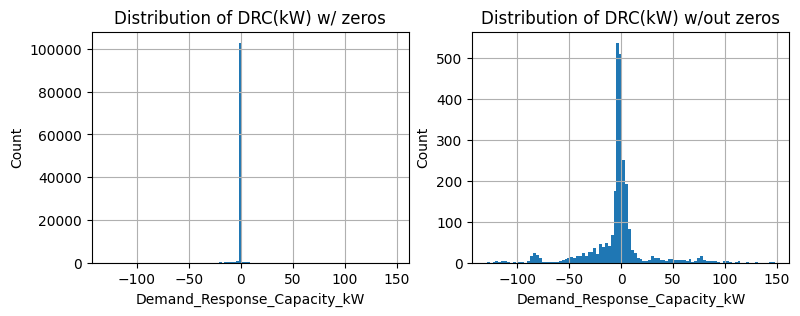

In [4]:
# perform some preprocessing
df = phase2_preprocess_data(df)
display(df.head())

# Visualize the distribution of Demand_Response_Capacity_kW
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(9, 3))
df['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax1)
ax1.set_title('Distribution of DRC(kW) w/ zeros')
ax1.set_xlabel('Demand_Response_Capacity_kW')
ax1.set_ylabel('Count')

df[
    df['Demand_Response_Capacity_kW'] != 0.0
]['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax2)
ax2.set_title('Distribution of DRC(kW) w/out zeros')
ax2.set_xlabel('Demand_Response_Capacity_kW')
ax2.set_ylabel('Count')
plt.show()

In [5]:
# Here we are gonna build 2 models:
# 1. Regression model to predict Demand_Response_Capacity_kW when Demand_Response_Flag = -1
# 2. Regression model to predict Demand_Response_Capacity_kW when Demand_Response_Flag = +1
# We know that when Demand_Response_Flag = 0, then Demand_Response_Capacity_kW is always 0.0

df = df.drop_duplicates()
df_neg = df[df['Demand_Response_Flag'] == -1].copy(deep=True)
df_pos = df[df['Demand_Response_Flag'] == 1].copy(deep=True)
print (df_neg.shape, df_pos.shape)

(2262, 14) (847, 14)


In [6]:
X = df_neg.drop(columns=['Demand_Response_Capacity_kW','Demand_Response_Flag']).values
y = df_neg['Demand_Response_Capacity_kW'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

def objective(params):
    reg_params = {
        'objective': 'reg:squarederror',
        'n_estimators': int(params['reg_n_estimators']),
        'max_depth': int(params['reg_max_depth']),
        'learning_rate': params['reg_learning_rate'],
        'gamma': params['reg_gamma'],
        'reg_lambda': params['reg_reg_lambda'],
        'reg_alpha': params['reg_reg_alpha'],
        'min_child_weight': int(params['min_child_weight']),
        'random_state': 42
    }
    reg = xgb.XGBRegressor(**reg_params)
    # reg = TransformedTargetRegressor(regressor=reg, func=np.arcsinh, inverse_func=np.sinh)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    score = mean_absolute_error(y_test, y_pred)
    return {'loss': score, 'status': STATUS_OK}


space = {
    'reg_n_estimators': hp.quniform('reg_n_estimators', 100, 500, 50),
    'reg_max_depth': hp.quniform('reg_max_depth', 3, 8, 1),
    'reg_learning_rate': hp.uniform('reg_learning_rate', 0.001, 0.2),
    'reg_gamma': hp.uniform('reg_gamma', 0.0, 10.0),
    'reg_reg_lambda': hp.uniform('reg_reg_lambda', 0.0, 10.0),
    'reg_reg_alpha': hp.uniform('reg_reg_alpha', 0.0, 10.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
}

use_hyperopt = False
if use_hyperopt:
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=500, trials=trials)
    print("Best hyperparameters:", best)
    sys.exit()

In [7]:
# For negative Demand_Response_Flag
X = df_neg.drop(columns=['Demand_Response_Capacity_kW','Demand_Response_Flag']).values
y = df_neg['Demand_Response_Capacity_kW'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

best_hyperparams = {
    'min_child_weight': np.float64(2.0),
    'reg_gamma': np.float64(0.7714379111158478),
    'reg_learning_rate': np.float64(0.14476246160423606),
    'reg_max_depth': np.float64(8.0),
    'reg_n_estimators': np.float64(400.0),
    'reg_reg_alpha': np.float64(7.835378971418742),
    'reg_reg_lambda': np.float64(6.349148595802035)
}
reg_neg = xgb.XGBRegressor(
    objective='reg:squarederror',
    # objective='reg:pseudohubererror',
    n_estimators=int(best_hyperparams['reg_n_estimators']),
    max_depth=int(best_hyperparams['reg_max_depth']),
    learning_rate=best_hyperparams['reg_learning_rate'],
    gamma=best_hyperparams['reg_gamma'],
    reg_lambda=best_hyperparams['reg_reg_lambda'],
    reg_alpha=best_hyperparams['reg_reg_alpha'],
    min_child_weight=int(best_hyperparams['min_child_weight']),
    random_state=42
).fit(X_train, y_train)

y_pred = reg_neg.predict(X_test)
print("Negative DRF Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

# print some statistics on y_test and y_pred
print(y_test.min(), y_test.max(), y_test.mean(), y_test.std())
print(y_pred.min(), y_pred.max(), y_pred.mean(), y_pred.std())


(2148, 12) (114, 12) (2148,) (114,)
Negative DRF Model Performance:
MAE: 5.169952430008796
RMSE: 11.851096935470444
R2: 0.5749171288987485
-81.35 31.21 -7.234473684210525 18.17698077201353
-84.362076 31.76122 -8.73671 18.458021


In [8]:
# For positive Demand_Response_Flag
X = df_pos.drop(columns=['Demand_Response_Capacity_kW','Demand_Response_Flag']).values
y = df_pos['Demand_Response_Capacity_kW'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

best_hyperparams = {
    'min_child_weight': np.float64(2.0),
    'reg_gamma': np.float64(0.18109230590577607),
    'reg_learning_rate': np.float64(0.09241855024383001),
    'reg_max_depth': np.float64(8.0),
    'reg_n_estimators': np.float64(400.0),
    'reg_reg_alpha': np.float64(3.7759458553717224),
    'reg_reg_lambda': np.float64(0.22040644589684041)
}
reg_pos = xgb.XGBRegressor(
    objective='reg:squarederror',
    # objective='reg:pseudohubererror',
    n_estimators=int(best_hyperparams['reg_n_estimators']),
    max_depth=int(best_hyperparams['reg_max_depth']),
    learning_rate=best_hyperparams['reg_learning_rate'],
    gamma=best_hyperparams['reg_gamma'],
    reg_lambda=best_hyperparams['reg_reg_lambda'],
    reg_alpha=best_hyperparams['reg_reg_alpha'],
    min_child_weight=int(best_hyperparams['min_child_weight']),
    random_state=42
).fit(X_train, y_train)

y_pred = reg_pos.predict(X_test)
print("Positive DRF Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

# print some statistics on y_test and y_pred
print(y_test.min(), y_test.max(), y_test.mean(), y_test.std())
print(y_pred.min(), y_pred.max(), y_pred.mean(), y_pred.std())


(804, 12) (43, 12) (804,) (43,)
Positive DRF Model Performance:
MAE: 3.8335946193406745
RMSE: 7.354619126547246
R2: 0.937149178860461
-1.4 112.84 17.533255813953488 29.33625748716362
-0.11569013 115.270706 17.553064 27.915794


In [9]:
# Save models
joblib.dump(reg_neg, './models/phase2_xgb_reg_neg_model.pkl')
joblib.dump(reg_pos, './models/phase2_xgb_reg_pos_model.pkl')
print("Models saved.")

Models saved.


### A different approach

In [10]:
df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
print(df.shape)
display(df.head())

(105120, 7)


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [11]:
def one_hot_encode_drf(df):
    # One-hot encode using 0/1 for each unique value in Demand_Response_Flag
    df['Demand_Response_Flag'] = df['Demand_Response_Flag'].astype(int)
    site_dummies = pd.get_dummies(df['Demand_Response_Flag'], prefix='Demand_Response_Flag', dtype=int)
    df = pd.concat([df, site_dummies], axis=1)
    df.drop(columns=['Demand_Response_Flag'], inplace=True)
    return df

In [ ]:
df = phase2_preprocess_data(df)
df = one_hot_encode_drf(df)

,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Capacity_kW,Hour,Day,DOW,Month,Weekday,Minute,Is_Weekend,Is_Summer,Is_Winter,Demand_Response_Flag_-1,Demand_Response_Flag_0,Demand_Response_Flag_1
0,22.20,0.0,4.8,0.0,0,1,1,1,1,0,0,0,1,0,1,0
1,22.27,0.0,4.8,0.0,0,1,1,1,1,15,0,0,1,0,1,0
2,22.35,0.0,4.8,0.0,0,1,1,1,1,30,0,0,1,0,1,0
3,22.42,0.0,4.8,0.0,0,1,1,1,1,45,0,0,1,0,1,0
4,22.50,0.0,4.8,0.0,1,1,1,1,1,0,0,0,1,0,1,0


In [15]:
# For positive Demand_Response_Flag
X = df.drop(columns=['Demand_Response_Capacity_kW']).values
y = df['Demand_Response_Capacity_kW'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(84096, 15) (21024, 15) (84096,) (21024,)


In [16]:
best_hyperparams = {
    'min_child_weight': np.float64(2.0),
    'reg_gamma': np.float64(0.7714379111158478),
    'reg_learning_rate': np.float64(0.14476246160423606),
    'reg_max_depth': np.float64(8.0),
    'reg_n_estimators': np.float64(400.0),
    'reg_reg_alpha': np.float64(7.835378971418742),
    'reg_reg_lambda': np.float64(6.349148595802035)
}
reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    # # objective='reg:pseudohubererror',
    # n_estimators=int(best_hyperparams['reg_n_estimators']),
    # max_depth=int(best_hyperparams['reg_max_depth']),
    # learning_rate=best_hyperparams['reg_learning_rate'],
    # gamma=best_hyperparams['reg_gamma'],
    # reg_lambda=best_hyperparams['reg_reg_lambda'],
    # reg_alpha=best_hyperparams['reg_reg_alpha'],
    # min_child_weight=int(best_hyperparams['min_child_weight']),
    random_state=42
).fit(X_train, y_train)

y_pred = reg.predict(X_test)
print("Combined DRF Model Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

Combined DRF Model Performance:
MAE: 0.19076377897082233
RMSE: 2.1741847168286794
R2: 0.7416779158717939
